In [25]:
import csv

import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42

# Specify each path

In [26]:
dataset = 'model/keypoint_classifier/keypoint.csv'
model_save_path = 'model/keypoint_classifier/keypoint_classifier.hdf5'
tflite_save_path = 'model/keypoint_classifier/keypoint_classifier.tflite'

# Set number of classes

In [27]:
NUM_CLASSES = 9

# Dataset reading

In [28]:
X_dataset = np.loadtxt(dataset, delimiter=',', dtype='float32', usecols=list(range(1, (21 * 2) + 1)))

In [29]:
y_dataset = np.loadtxt(dataset, delimiter=',', dtype='int32', usecols=(0))

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X_dataset, y_dataset, train_size=0.75, random_state=RANDOM_SEED)

# Model building

In [31]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input((21 * 2, )),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(20, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
])

In [32]:
model.summary()  # tf.keras.utils.plot_model(model, show_shapes=True)

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dropout_2 (Dropout)         (None, 42)                0         
                                                                 
 dense_3 (Dense)             (None, 20)                860       
                                                                 
 dropout_3 (Dropout)         (None, 20)                0         
                                                                 
 dense_4 (Dense)             (None, 10)                210       
                                                                 
 dense_5 (Dense)             (None, 9)                 99        
                                                                 
Total params: 1169 (4.57 KB)
Trainable params: 1169 (4.57 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [33]:
# Model checkpoint callback
cp_callback = tf.keras.callbacks.ModelCheckpoint(
    model_save_path, verbose=1, save_weights_only=False)
# Callback for early stopping
es_callback = tf.keras.callbacks.EarlyStopping(patience=20, verbose=1)

In [34]:
# Model compilation
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Model training

In [35]:
model.fit(
    X_train,
    y_train,
    epochs=1500,
    batch_size=128,
    validation_data=(X_test, y_test),
    callbacks=[cp_callback, es_callback]
)

Epoch 1/1500
56/76 [=====================>........] - ETA: 0s - loss: 2.2189 - accuracy: 0.1299
Epoch 1: saving model to model/keypoint_classifier/keypoint_classifier.hdf5
76/76 [==============================] - 1s 4ms/step - loss: 2.1926 - accuracy: 0.1452 - val_loss: 2.0429 - val_accuracy: 0.2597
Epoch 2/1500
23/76 [========>.....................] - ETA: 0s - loss: 2.0775 - accuracy: 0.2089

/home/mehregan/smart_class/lib64/python3.10/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


73/76 [===========================>..] - ETA: 0s - loss: 2.0396 - accuracy: 0.2322
Epoch 2: saving model to model/keypoint_classifier/keypoint_classifier.hdf5
76/76 [==============================] - 0s 4ms/step - loss: 2.0386 - accuracy: 0.2332 - val_loss: 1.9097 - val_accuracy: 0.2887
Epoch 3/1500
55/76 [====================>.........] - ETA: 0s - loss: 1.9394 - accuracy: 0.2777
Epoch 3: saving model to model/keypoint_classifier/keypoint_classifier.hdf5
76/76 [==============================] - 0s 3ms/step - loss: 1.9185 - accuracy: 0.2862 - val_loss: 1.7639 - val_accuracy: 0.3904
Epoch 4/1500
48/76 [=================>............] - ETA: 0s - loss: 1.8367 - accuracy: 0.3053
Epoch 4: saving model to model/keypoint_classifier/keypoint_classifier.hdf5
76/76 [==============================] - 0s 2ms/step - loss: 1.8172 - accuracy: 0.3127 - val_loss: 1.6517 - val_accuracy: 0.4035
Epoch 5/1500
52/76 [===================>..........] - ETA: 0s - loss: 1.7471 - accuracy: 0.3311
Epoch 5: savin

In [36]:
# Model evaluation
val_loss, val_acc = model.evaluate(X_test, y_test, batch_size=128)

26/26 [==============================] - 0s 3ms/step - loss: 0.7757 - accuracy: 0.7633


In [37]:
# Loading the saved model
model = tf.keras.models.load_model(model_save_path)

In [38]:
# Inference test
predict_result = model.predict(np.array([X_test[0]]))
print(np.squeeze(predict_result))
print(np.argmax(np.squeeze(predict_result)))

1/1 [==============================] - 0s 111ms/step
[1.4984062e-01 2.9921429e-03 3.1083255e-06 1.3526283e-05 1.3095438e-01
 5.6401569e-01 1.5161276e-01 3.8028017e-07 5.6738610e-04]
5


# Confusion matrix

101/101 [==============================] - 0s 1ms/step


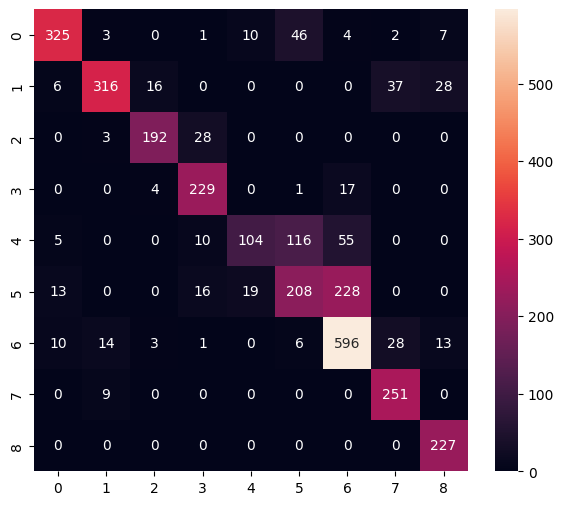

Classification Report
              precision    recall  f1-score   support

           0       0.91      0.82      0.86       398
           1       0.92      0.78      0.84       403
           2       0.89      0.86      0.88       223
           3       0.80      0.91      0.85       251
           4       0.78      0.36      0.49       290
           5       0.55      0.43      0.48       484
           6       0.66      0.89      0.76       671
           7       0.79      0.97      0.87       260
           8       0.83      1.00      0.90       227

    accuracy                           0.76      3207
   macro avg       0.79      0.78      0.77      3207
weighted avg       0.77      0.76      0.75      3207



In [39]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

def print_confusion_matrix(y_true, y_pred, report=True):
    labels = sorted(list(set(y_true)))
    cmx_data = confusion_matrix(y_true, y_pred, labels=labels)
    
    df_cmx = pd.DataFrame(cmx_data, index=labels, columns=labels)
 
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(df_cmx, annot=True, fmt='g' ,square=False)
    ax.set_ylim(len(set(y_true)), 0)
    plt.show()
    
    if report:
        print('Classification Report')
        print(classification_report(y_test, y_pred))

Y_pred = model.predict(X_test)
y_pred = np.argmax(Y_pred, axis=1)

print_confusion_matrix(y_test, y_pred)

# Convert to model for Tensorflow-Lite

In [40]:
# Save as a model dedicated to inference
model.save(model_save_path, include_optimizer=False)

/home/mehregan/smart_class/lib64/python3.10/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [41]:
# Transform model (quantization)

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quantized_model = converter.convert()

open(tflite_save_path, 'wb').write(tflite_quantized_model)

INFO:tensorflow:Assets written to: /tmp/tmp3zl14kzj/assets


INFO:tensorflow:Assets written to: /tmp/tmp3zl14kzj/assets
2026-01-03 19:50:13.927589: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
2026-01-03 19:50:13.927615: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2026-01-03 19:50:13.927764: I tensorflow/cc/saved_model/reader.cc:45] Reading SavedModel from: /tmp/tmp3zl14kzj
2026-01-03 19:50:13.928328: I tensorflow/cc/saved_model/reader.cc:91] Reading meta graph with tags { serve }
2026-01-03 19:50:13.928338: I tensorflow/cc/saved_model/reader.cc:132] Reading SavedModel debug info (if present) from: /tmp/tmp3zl14kzj
2026-01-03 19:50:13.929802: I tensorflow/cc/saved_model/loader.cc:231] Restoring SavedModel bundle.
2026-01-03 19:50:13.950412: I tensorflow/cc/saved_model/loader.cc:215] Running initialization op on SavedModel bundle at path: /tmp/tmp3zl14kzj
2026-01-03 19:50:13.956552: I tensorflow/cc/saved_model/loader.cc:314] SavedModel

6808

# Inference test

In [42]:
interpreter = tf.lite.Interpreter(model_path=tflite_save_path)
interpreter.allocate_tensors()

In [43]:
# Get I / O tensor
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

In [44]:
interpreter.set_tensor(input_details[0]['index'], np.array([X_test[0]]))

In [45]:
%%time
# Inference implementation
interpreter.invoke()
tflite_results = interpreter.get_tensor(output_details[0]['index'])

CPU times: user 629 μs, sys: 0 ns, total: 629 μs
Wall time: 559 μs


In [46]:
print(np.squeeze(tflite_results))
print(np.argmax(np.squeeze(tflite_results)))

[1.4984074e-01 2.9921392e-03 3.1083143e-06 1.3526221e-05 1.3095425e-01
 5.6401581e-01 1.5161264e-01 3.8027807e-07 5.6738459e-04]
5
